# Working with unstructured meshes in xESMF

xESMF can now build regridders from UGRID-style unstructured mesh inputs using
`mesh_in=True`. This makes it possible to regrid face-centered data from an
unstructured source mesh to a structured output grid. For real-world
unstructured mesh files, we recommend using
[UXarray](https://uxarray.readthedocs.io/en/latest/) to read the mesh and
normalize its topology metadata into a consistent UGRID-style representation
before passing it to xESMF. UXarray is used in this notebook only as a
convenient way to load public example meshes; xESMF itself consumes xarray
datasets with mesh coordinates and connectivity.

Currently supported:

- Face-centered and node-centered source data on mesh faces.
- Mesh-to-structured-grid regridding.
- Spherical longitude/latitude mesh coordinates.
- Cartesian xyz mesh coordinates.
- `bilinear`, `patch`, `nearest_s2d`, and `nearest_d2s` methods.
- UGRID-style `_FillValue` and `start_index` metadata on face-node connectivity.

Not yet supported:

- Edge-centered source data.
- Conservative mesh regridding methods.
- Mesh output grids.


In [1]:
import numpy as np
import xarray as xr
import uxarray as ux
import xesmf as xe
import matplotlib.pyplot as plt

## Download example mesh files

This notebook uses small public example files from the UXarray repository. The
helper below downloads each file once and reuses it from a local cache on
subsequent runs, so the example data do not need to be stored in the xESMF
repository.

If you prefer, you can also download these files manually from the UXarray
repository and pass the local file paths directly to `ux.open_dataset`.


In [2]:
from pathlib import Path
from urllib.request import urlretrieve

CACHE_DIR = Path.home() / ".cache" / "xesmf-uxarray"
CACHE_DIR.mkdir(parents=True, exist_ok=True)


def fetch_uxarray_example(filename, base_url):
    """Download a UXarray example file once and reuse it from a local cache."""
    local_path = CACHE_DIR / filename
    if not local_path.exists():
        url = f"{base_url.rstrip('/')}/{filename}"
        print(f"Downloading {url}")
        urlretrieve(url, local_path)
    return local_path

## Regridding a small MPAS example mesh

We start with a small subset of a 30 km MPAS atmosphere mesh from the UXarray
example data repository. The example consists of a separate grid file and data
file. UXarray reads the MPAS files and exposes the mesh in a normalized form
with face centers, node coordinates, and face-node connectivity.

The data file contains face-centered example fields, including `gaussian` and
`inverse_gaussian`, which makes it a compact test case for regridding from an
unstructured mesh to a structured latitude-longitude grid.


In [3]:
base_url = "https://raw.githubusercontent.com/UXARRAY/uxarray/main/test/meshfiles/mpas/dyamond-30km"

grid_path = fetch_uxarray_example("gradient_grid_subset.nc", base_url)
data_path = fetch_uxarray_example("gradient_data_subset.nc", base_url)

uxds = ux.open_dataset(grid_path, data_path)
uxds.data_vars

Data variables:
    face_lat          (n_face) float32 780B ...
    face_lon          (n_face) float32 780B ...
    gaussian          (n_face) float32 780B ...
    inverse_gaussian  (n_face) float32 780B ...

Next, we define a simple structured latitude-longitude target grid covering the
same longitude and latitude range as the source mesh. This will be the grid that
the unstructured face-centered data are regridded onto.


In [4]:
g = uxds.uxgrid
lon0, lon1 = float(g.face_lon.min()), float(g.face_lon.max())
lat0, lat1 = float(g.face_lat.min()), float(g.face_lat.max())

dst = xe.util.cf_grid_2d(
    lon0,
    lon1,
    (lon1 - lon0) / 80,
    lat0,
    lat1,
    (lat1 - lat0) / 60,
)

In [5]:
regridder = xe.Regridder(
    uxds,
    dst,
    "bilinear",
    mesh_in=True,
    unmapped_to_nan=True,
)
out = regridder(uxds["gaussian"])

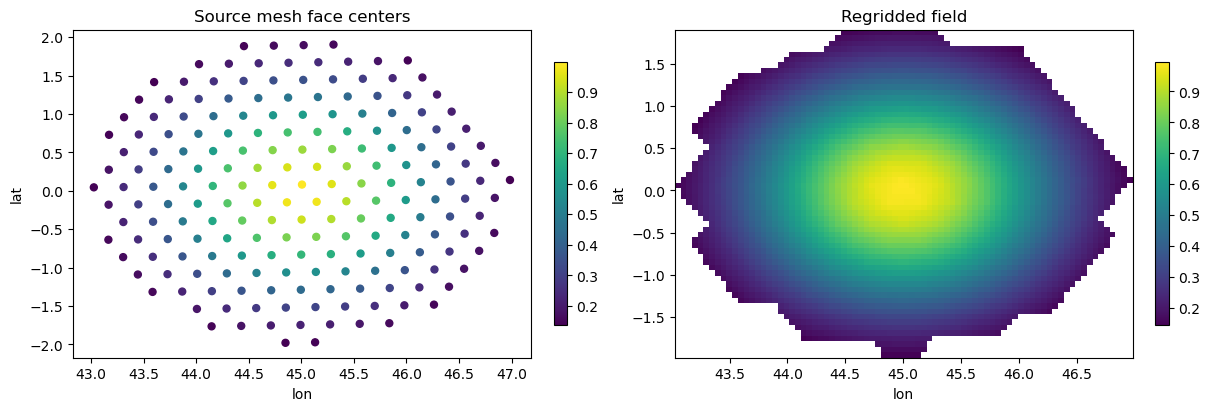

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

sc = axes[0].scatter(
    uxds.uxgrid.face_lon.values,
    uxds.uxgrid.face_lat.values,
    c=uxds["gaussian"].values,
    s=25,
    cmap="viridis",
)
axes[0].set_title("Source mesh face centers")
axes[0].set_xlabel("lon")
axes[0].set_ylabel("lat")
plt.colorbar(sc, ax=axes[0], shrink=0.8)

pcm = axes[1].pcolormesh(
    dst["lon"].values,
    dst["lat"].values,
    out.values,
    shading="auto",
    cmap="viridis",
)
axes[1].set_title("Regridded field")
axes[1].set_xlabel("lon")
axes[1].set_ylabel("lat")
plt.colorbar(pcm, ax=axes[1], shrink=0.8)

## Regridding a larger MPAS-Ocean mesh

Next we apply the same workflow to a larger MPAS-Ocean example. The file
contains both the mesh and the face-centered `bottomDepth` field. We use UXarray
to read the file, convert the normalized mesh representation into xESMF's
explicit mesh input format, and regrid the field to a structured
latitude-longitude grid. This example does not define an explicit source or
target mask. For fields such as `bottomDepth`, adding an appropriate land/ocean
mask can improve the behavior near coastlines and unmapped regions. See the
Masking notebook for more details on using masks with xESMF.


In [7]:
BASE_URL = "https://raw.githubusercontent.com/UXARRAY/uxarray/main/test/meshfiles/mpas/QU"
FILENAME = "oQU480.231010.nc"

oqu_path = fetch_uxarray_example(FILENAME, BASE_URL)
uxds = ux.open_dataset(oqu_path, oqu_path)
uxds

<xarray.UxDataset> Size: 5MB
Dimensions:                   (n_face: 1791, n_edge: 5754, n_node: 3947,
                               n_max_face_nodes: 6, maxEdges2: 12, TWO: 2,
                               vertexDegree: 3, nVertLevels: 60, Time: 1)
Dimensions without coordinates: n_face, n_edge, n_node, n_max_face_nodes,
                                maxEdges2, TWO, vertexDegree, nVertLevels, Time
Data variables: (12/55)
    latCell                   (n_face) float64 14kB ...
    lonCell                   (n_face) float64 14kB ...
    xCell                     (n_face) float64 14kB ...
    yCell                     (n_face) float64 14kB ...
    zCell                     (n_face) float64 14kB ...
    indexToCellID             (n_face) int32 7kB ...
    ...                        ...
    refTopDepth               (nVertLevels) float64 480B ...
    refZMid                   (nVertLevels) float64 480B ...
    refLayerThickness         (nVertLevels) float64 480B ...
    layerThickness            (Time, n_face, nVertLevels) float64 860kB ...
    ssh                       (Time, n_face) float64 14kB ...
    zMid                      (Time, n_face, nVertLevels) float64 860kB ...
Attributes:
    on_a_sphere:    YES
    sphere_radius:  6371229.0
    is_periodic:    NO
    parent_id:      kufh9o2jwx\nlsd2k42w1r\na4x6sqhkwb
    history:        Tue Oct 10 16:52:25 2023: ./convert.py\nMpasMeshConverter...
    mesh_spec:      1.0
    Conventions:    MPAS
    source:         MpasMeshConverter.x
    file_id:        85scxk6tmk

In [8]:
dst = xe.util.grid_global(2, 1.5, cf=True)
dst

<xarray.Dataset> Size: 7kB
Dimensions:             (lon: 180, lat: 120, bound: 2)
Coordinates:
  * lon                 (lon) float64 1kB -179.0 -177.0 -175.0 ... 177.0 179.0
  * lat                 (lat) float64 960B -89.25 -87.75 -86.25 ... 87.75 89.25
    lon_bounds          (lon, bound) float64 3kB -180.0 -178.0 ... 178.0 180.0
    lat_bounds          (lat, bound) float64 2kB -90.0 -88.5 -88.5 ... 88.5 90.0
    latitude_longitude  float64 8B nan
Dimensions without coordinates: bound
Data variables:
    *empty*

In [9]:
regridder = xe.Regridder(
    uxds,
    dst,
    "bilinear",
    mesh_in=True,
    mesh_location="face",
    unmapped_to_nan=True,
)
out = regridder(uxds["bottomDepth"])

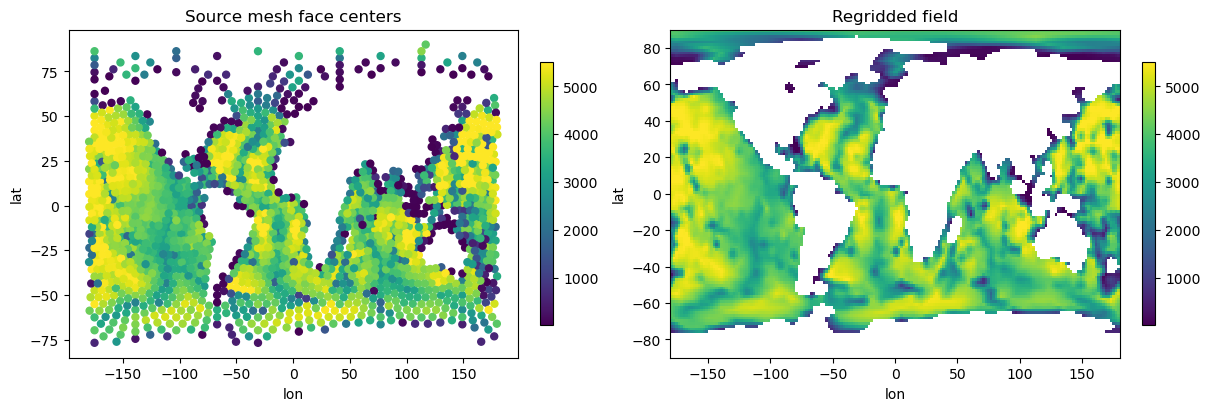

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

sc = axes[0].scatter(
    uxds.uxgrid.face_lon.values,
    uxds.uxgrid.face_lat.values,
    c=uxds["bottomDepth"].values,
    s=25,
    cmap="viridis",
)
axes[0].set_title("Source mesh face centers")
axes[0].set_xlabel("lon")
axes[0].set_ylabel("lat")
plt.colorbar(sc, ax=axes[0], shrink=0.8)

pcm = axes[1].pcolormesh(
    dst["lon"].values,
    dst["lat"].values,
    out.values,
    shading="auto",
    cmap="viridis",
)
axes[1].set_title("Regridded field")
axes[1].set_xlabel("lon")
axes[1].set_ylabel("lat")
plt.colorbar(pcm, ax=axes[1], shrink=0.8)

## Regridding a FESOM field

The previous examples used MPAS meshes. Here we repeat the same workflow with a
FESOM 2.1 example from the UXarray test data repository. The mesh topology is
stored in a separate UGRID-style mesh file, while the model output is stored in
a separate data file.

This example uses the face-centered zonal velocity variable `u`. The variable is
three-dimensional, with dimensions `time`, `nz1`, and `n_face`, so we select one
time step and one vertical level before regridding.


### Regridding FESOM SST (node centered source data)


In [11]:
BASE_URL = "https://raw.githubusercontent.com/UXARRAY/uxarray/main/test/meshfiles/ugrid/fesom"
MESH_FILENAME = "fesom.mesh.diag.nc"
DATA_FILENAME = "sst.fesom.1948.nc"
mesh_path = fetch_uxarray_example(MESH_FILENAME, BASE_URL)
data_path = fetch_uxarray_example(DATA_FILENAME, BASE_URL)

In [12]:
uxds = ux.open_dataset(mesh_path, data_path)
field = uxds["sst"].isel(time=0)
field

<xarray.UxDataArray 'sst' (n_node: 3140)> Size: 25kB
[3140 values with dtype=float64]
Coordinates:
    time     datetime64[ns] 8B 1948-01-01T23:45:00
Dimensions without coordinates: n_node
Attributes:
    description:  sea surface temperature
    long_name:    sea surface temperature
    units:        C
    location:     node
    mesh:         fesom_mesh

In [13]:
dst = xe.util.grid_global(2, 1.5, cf=True)
dst

<xarray.Dataset> Size: 7kB
Dimensions:             (lon: 180, lat: 120, bound: 2)
Coordinates:
  * lon                 (lon) float64 1kB -179.0 -177.0 -175.0 ... 177.0 179.0
  * lat                 (lat) float64 960B -89.25 -87.75 -86.25 ... 87.75 89.25
    lon_bounds          (lon, bound) float64 3kB -180.0 -178.0 ... 178.0 180.0
    lat_bounds          (lat, bound) float64 2kB -90.0 -88.5 -88.5 ... 88.5 90.0
    latitude_longitude  float64 8B nan
Dimensions without coordinates: bound
Data variables:
    *empty*

In [14]:
regridder = xe.Regridder(
    uxds,
    dst,
    "bilinear",
    mesh_in=True,
    unmapped_to_nan=True,
)
out = regridder(field)

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.
/Users/ali/xESMF/xesmf/frontend.py:378: UserWarning: face_node_connectivity start_index metadata is inconsistent with the connectivity values; falling back to inferred start_index=0
  warnings.warn(


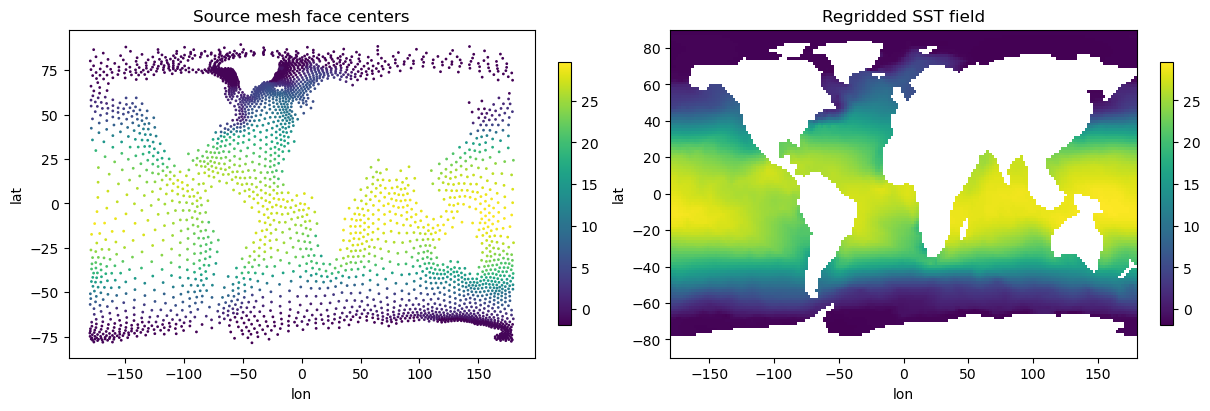

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

sc = axes[0].scatter(
    uxds.uxgrid.node_lon.values,
    uxds.uxgrid.node_lat.values,
    c=field.values,
    s=1,
    cmap="viridis",
)
axes[0].set_title("Source mesh face centers")
axes[0].set_xlabel("lon")
axes[0].set_ylabel("lat")
plt.colorbar(sc, ax=axes[0], shrink=0.8)

pcm = axes[1].pcolormesh(
    dst["lon"].values,
    dst["lat"].values,
    out.values,
    shading="auto",
    cmap="viridis",
)
axes[1].set_title("Regridded SST field")
axes[1].set_xlabel("lon")
axes[1].set_ylabel("lat")
plt.colorbar(pcm, ax=axes[1], shrink=0.8)

### Regridding FESOM Horizontal Velocity (face centered data)


In [16]:
BASE_URL = "https://raw.githubusercontent.com/UXARRAY/uxarray/main/test/meshfiles/ugrid/fesom"
MESH_FILENAME = "fesom.mesh.diag.nc"
DATA_FILENAME = "u.fesom.1948.nc"
mesh_path = fetch_uxarray_example(MESH_FILENAME, BASE_URL)
data_path = fetch_uxarray_example(DATA_FILENAME, BASE_URL)

In [17]:
uxds = ux.open_dataset(mesh_path, data_path)
field = uxds["u"].isel(time=0, nz1=0)
field

<xarray.UxDataArray 'u' (n_face: 5839)> Size: 47kB
[5839 values with dtype=float64]
Coordinates:
    nz1      float64 8B 2.5
    time     datetime64[ns] 8B 1948-01-01T23:45:00
Dimensions without coordinates: n_face
Attributes:
    description:  horizontal velocity
    long_name:    horizontal velocity
    units:        m/s
    location:     face
    mesh:         fesom_mesh

In [18]:
regridder = xe.Regridder(
    uxds,
    dst,
    "bilinear",
    mesh_in=True,
    unmapped_to_nan=True,
)
out = regridder(field)

/Users/ali/xESMF/xesmf/frontend.py:378: UserWarning: face_node_connectivity start_index metadata is inconsistent with the connectivity values; falling back to inferred start_index=0
  warnings.warn(


> This warning is important !!! Always check the connectivity metadata when
> working with real-world mesh files. Some workflows may normalize connectivity
> values but leave metadata behind, for example zero-based connectivity values
> with `start_index=1`. xESMF validates the connectivity range and resolves the
> effective `start_index` when possible.


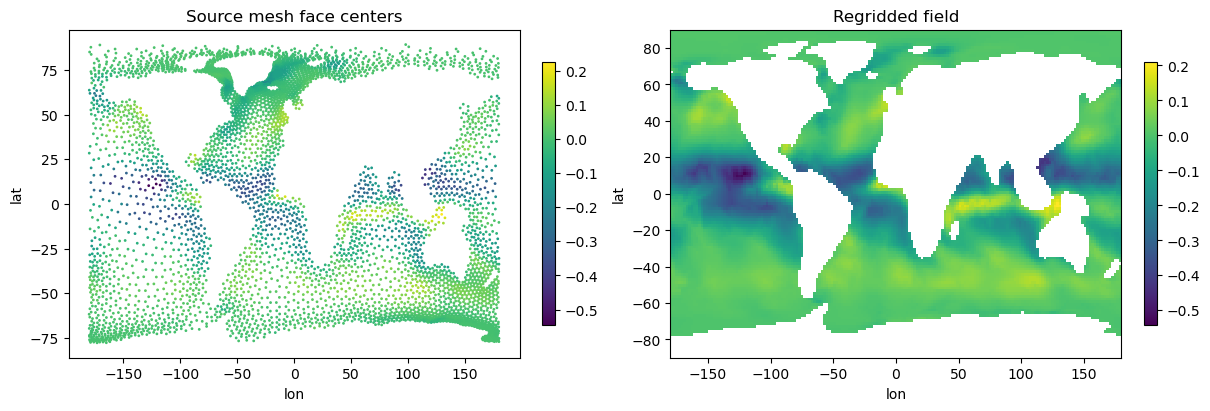

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

sc = axes[0].scatter(
    uxds.uxgrid.face_lon.values,
    uxds.uxgrid.face_lat.values,
    c=field.values,
    s=1,
    cmap="viridis",
)
axes[0].set_title("Source mesh face centers")
axes[0].set_xlabel("lon")
axes[0].set_ylabel("lat")
plt.colorbar(sc, ax=axes[0], shrink=0.8)

pcm = axes[1].pcolormesh(
    dst["lon"].values,
    dst["lat"].values,
    out.values,
    shading="auto",
    cmap="viridis",
)
axes[1].set_title("Regridded field")
axes[1].set_xlabel("lon")
axes[1].set_ylabel("lat")
plt.colorbar(pcm, ax=axes[1], shrink=0.8)

## Regridding an ICON mesh

As a final example, we use an ICON grid file. ICON uses an icosahedral
unstructured grid: the sphere is covered by triangular cells derived from
refinements of an icosahedron. This differs from the MPAS and FESOM examples
above, and provides another useful check that xESMF can consume UGRID-style mesh
topology from different model families.

This file contains the grid description but no physical model output field. To
test the regridding workflow, we create a synthetic face-centered analytic field
from the ICON face-center longitude and latitude coordinates, then regrid it to
a structured latitude-longitude grid.


In [20]:
BASE_URL = "https://raw.githubusercontent.com/UXARRAY/uxarray/main/test/meshfiles/icon/R02B04"
FILENAME = "icon_grid_0010_R02B04_G.nc"
path = fetch_uxarray_example(FILENAME, BASE_URL)
uxds = ux.open_dataset(path, path)
uxds

<xarray.UxDataset> Size: 15MB
Dimensions:                        (n_face: 20480, n_max_face_nodes: 3,
                                    n_node: 10242, ne: 6, n_edge: 30720, no: 4,
                                    two: 2, two_grf: 2, cell_grf: 14,
                                    max_chdom: 1, edge_grf: 24, vert_grf: 13,
                                    vert_delaunay: 3, cell_delaunay: 40956)
Coordinates:
    clon                           (n_face) float64 164kB ...
    clat                           (n_face) float64 164kB ...
    vlon                           (n_node) float64 82kB ...
    vlat                           (n_node) float64 82kB ...
    elon                           (n_edge) float64 246kB ...
    elat                           (n_edge) float64 246kB ...
Dimensions without coordinates: n_face, n_max_face_nodes, n_node, ne, n_edge,
                                no, two, two_grf, cell_grf, max_chdom,
                                edge_grf, vert_grf, vert_delaunay, cell_delaunay
Data variables: (12/63)
    clon_vertices                  (n_face, n_max_face_nodes) float64 492kB ...
    clat_vertices                  (n_face, n_max_face_nodes) float64 492kB ...
    vlon_vertices                  (n_node, ne) float64 492kB ...
    vlat_vertices                  (n_node, ne) float64 492kB ...
    elon_vertices                  (n_edge, no) float64 983kB ...
    elat_vertices                  (n_edge, no) float64 983kB ...
    ...                             ...
    parent_edge_index              (n_edge) int32 123kB ...
    child_edge_index               (no, n_edge) int32 492kB ...
    child_edge_id                  (n_edge) int32 123kB ...
    phys_cell_id                   (n_face) int32 82kB ...
    phys_edge_id                   (n_edge) int32 123kB ...
    cc_delaunay                    (vert_delaunay, cell_delaunay) int32 491kB ...
Attributes: (12/21)
    title:                ICON grid description
    history:              /e/uhome/dreinert/icon/build/sx9
    institution:          Max Planck Institute for Meteorology/Deutscher Wett...
    source:               icon-dev
    uuidOfHGrid:          66a341d2-1dcf-11b2-880c-0f1645f3d1dc
    number_of_grid_used:  10
    ...                   ...
    inverse_flattening:   0.0
    grid_level:           4
    grid_root:            2
    grid_ID:              1
    parent_grid_ID:       0
    max_childdom:         1

Here we build an analytic field


In [21]:
face_lon = uxds.uxgrid.face_lon.values
face_lat = uxds.uxgrid.face_lat.values
analytic = xe.data.wave_smooth(face_lon, face_lat)

In [22]:
dst = xe.util.grid_global(2, 1.5, cf=True)
dst

<xarray.Dataset> Size: 7kB
Dimensions:             (lon: 180, lat: 120, bound: 2)
Coordinates:
  * lon                 (lon) float64 1kB -179.0 -177.0 -175.0 ... 177.0 179.0
  * lat                 (lat) float64 960B -89.25 -87.75 -86.25 ... 87.75 89.25
    lon_bounds          (lon, bound) float64 3kB -180.0 -178.0 ... 178.0 180.0
    lat_bounds          (lat, bound) float64 2kB -90.0 -88.5 -88.5 ... 88.5 90.0
    latitude_longitude  float64 8B nan
Dimensions without coordinates: bound
Data variables:
    *empty*

In [23]:
regridder = xe.Regridder(
    uxds,
    dst,
    "bilinear",
    mesh_in=True,
    mesh_location="face",
    unmapped_to_nan=True,
)
out = regridder(analytic)

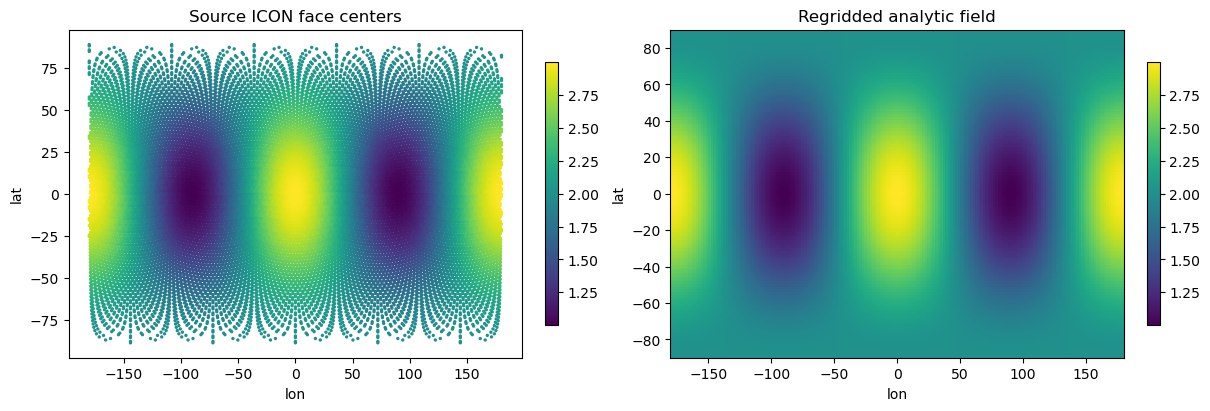

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

sc = axes[0].scatter(
    uxds.uxgrid.face_lon.values,
    uxds.uxgrid.face_lat.values,
    c=analytic,
    s=2,
    cmap="viridis",
)
axes[0].set_title("Source ICON face centers")
axes[0].set_xlabel("lon")
axes[0].set_ylabel("lat")
plt.colorbar(sc, ax=axes[0], shrink=0.8)

pcm = axes[1].pcolormesh(
    dst["lon"].values,
    dst["lat"].values,
    out,
    shading="auto",
    cmap="viridis",
)
axes[1].set_title("Regridded analytic field")
axes[1].set_xlabel("lon")
axes[1].set_ylabel("lat")
plt.colorbar(pcm, ax=axes[1], shrink=0.8)